In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Data

In [87]:
df = pd.read_csv(r"C:\Users\pc\Downloads\messy_ecommerce_returns_dataset.csv")

In [88]:
df

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date
0,1102,NaN,South,2532.19,Delivered,2024-01-17,2024-01-14
1,1179,NaN,East,3024.53,returned,2024-04-10,2024-04-14
2,1092,electrnics,North,1737.80,returned,2024-04-12,2024-04-08
3,1014,NaN,NaN,3877.47,Delivered,2024-05-03,2024-05-10
4,1106,Home,South,622.33,returned,2024-02-21,2024-03-05
...,...,...,...,...,...,...,...
515,1151,Electronics,West,2992.13,Returned,2024-04-01,2024-04-08
516,1130,electrnics,South,1868.77,returned,2024-01-14,2024-01-23
517,1149,electrnics,South,548.75,returned,2024-03-26,2024-03-22
518,1052,electrnics,East,4594.84,Delivered,2024-05-12,2024-05-17


# Basic Data Understanding

In [89]:
df.shape

(520, 7)

In [90]:
df.columns

Index(['Order_ID', 'Category', 'Zone', 'Amount', 'Status', 'Order_Date',
       'Delivery_Date'],
      dtype='object')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       520 non-null    int64  
 1   Category       414 non-null    object 
 2   Zone           436 non-null    object 
 3   Amount         500 non-null    float64
 4   Status         392 non-null    object 
 5   Order_Date     520 non-null    object 
 6   Delivery_Date  520 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 28.6+ KB


In [92]:
df.describe()

,Order_ID,Amount
count,520.000000,500.000000
mean,1101.309615,3016.048940
std,56.830295,3866.693145
min,1000.000000,124.210000
25%,1052.000000,1322.202500
50%,1103.000000,2769.255000
75%,1147.500000,3938.540000
max,1199.000000,48525.700000


In [93]:
df.head()

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date
0,1102,NaN,South,2532.19,Delivered,2024-01-17,2024-01-14
1,1179,NaN,East,3024.53,returned,2024-04-10,2024-04-14
2,1092,electrnics,North,1737.80,returned,2024-04-12,2024-04-08
3,1014,NaN,NaN,3877.47,Delivered,2024-05-03,2024-05-10
4,1106,Home,South,622.33,returned,2024-02-21,2024-03-05


# 3.Data Quality Check

### 1 .Duplicate Values

In [94]:
df.duplicated().sum()    # finding duplicater values 

np.int64(20)

In [95]:
df[df.duplicated()]

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date
500,1102,NaN,South,2532.19,Delivered,2024-01-17,2024-01-14
501,1179,NaN,East,3024.53,returned,2024-04-10,2024-04-14
502,1092,electrnics,North,1737.80,returned,2024-04-12,2024-04-08
503,1014,NaN,NaN,3877.47,Delivered,2024-05-03,2024-05-10
504,1106,Home,South,622.33,returned,2024-02-21,2024-03-05
505,1071,Beauty,West,468.18,Delivered,2024-02-21,2024-03-03
506,1188,Clothing,NORTH,3668.12,NaN,2024-06-12,2024-06-20
507,1020,Home,South,2527.91,Returned,2024-05-03,2024-05-09
508,1102,NaN,North,3473.17,Returned,2024-06-14,2024-06-20
509,1121,electrnics,West,2230.65,returned,2024-06-26,2024-07-01


In [96]:
df.drop_duplicates(subset = 'Order_ID' , keep = 'last' , inplace = True)  # Treating suplicate values

In [97]:
df.duplicated().sum()

np.int64(0)

### 2. Fixing Date Column 

In [98]:
df['Order_Date'] = pd.to_datetime( df['Order_Date'] , errors = 'coerce')
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'] , errors = 'coerce')

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 43 to 519
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       180 non-null    int64         
 1   Category       146 non-null    object        
 2   Zone           153 non-null    object        
 3   Amount         173 non-null    float64       
 4   Status         146 non-null    object        
 5   Order_Date     180 non-null    datetime64[ns]
 6   Delivery_Date  180 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(3)
memory usage: 11.2+ KB


### 3 . Treating Inconsistent Data

In [100]:
categorical_col = df.select_dtypes( include = 'object').columns
categorical_col

Index(['Category', 'Zone', 'Status'], dtype='object')

In [101]:
for col in categorical_col:
    print(f' {col} value_counts')
    print(df[col].value_counts())

 Category value_counts
Category
Home           32
Electronics    31
electrnics     30
Beauty         27
Clothing       26
Name: count, dtype: int64
 Zone value_counts
Zone
East     34
South    34
North    30
NORTH    30
West     25
Name: count, dtype: int64
 Status value_counts
Status
Delivered    54
Returned     50
returned     42
Name: count, dtype: int64


In [102]:
df['Category'] = df['Category'].replace({'electrnics' : 'Electronics' , })
df['Zone'] = df['Zone'].replace({'NORTH' : 'North'})
df['Status'] = df['Status'].replace({'returned' : 'Returned'})

In [103]:
for col in categorical_col:
    print(f' {col} value_counts')
    print(df[col].value_counts())

 Category value_counts
Category
Electronics    61
Home           32
Beauty         27
Clothing       26
Name: count, dtype: int64
 Zone value_counts
Zone
North    60
South    34
East     34
West     25
Name: count, dtype: int64
 Status value_counts
Status
Returned     92
Delivered    54
Name: count, dtype: int64


### 4.Treating Missing Values

In [104]:
df.isnull().sum() 

Order_ID          0
Category         34
Zone             27
Amount            7
Status           34
Order_Date        0
Delivery_Date     0
dtype: int64

In [105]:
df['Category'] = df['Category'].fillna('Unknown')
df['Zone'] = df['Zone'].fillna(df['Zone'].mode()[0])
df['Amount'] = df['Amount'].fillna(df['Amount'].median())
df['Status'] = df['Status'].fillna('Unknown')

In [106]:
df.isnull().sum() 

Order_ID         0
Category         0
Zone             0
Amount           0
Status           0
Order_Date       0
Delivery_Date    0
dtype: int64

### 5.Treating Outliners

In [107]:
df['Amount'].skew()

np.float64(8.396686099772136)

In [108]:
from feature_engine.outliers import Winsorizer
win = Winsorizer(capping_method='iqr', tail='both', variables = ['Amount'])

df[['Amount']] = win.fit_transform(df[["Amount"]])

In [75]:
df['Amount'].skew()

np.float64(0.3602913359514156)

In [110]:
df.shape

(180, 7)

In [111]:
df['Return_Flag'] = df['Status'].apply(lambda x: 1 if x=='Returned' else 0)

df['Delivery_Days'] = (pd.to_datetime(df['Delivery_Date']) - pd.to_datetime(df['Order_Date'])).dt.days


In [112]:
df

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date,Return_Flag,Delivery_Days
43,1063,Unknown,West,1557.01,Unknown,2024-03-22,2024-04-05,0,14
48,1072,Home,North,4324.01,Delivered,2024-01-21,2024-02-01,0,11
49,1166,Beauty,North,4238.29,Delivered,2024-02-11,2024-02-24,0,13
84,1013,Home,North,3864.54,Returned,2024-05-08,2024-05-10,1,2
90,1039,Unknown,South,1837.65,Returned,2024-05-12,2024-05-21,1,9
...,...,...,...,...,...,...,...,...,...
515,1151,Electronics,West,2992.13,Returned,2024-04-01,2024-04-08,1,7
516,1130,Electronics,South,1868.77,Returned,2024-01-14,2024-01-23,1,9
517,1149,Electronics,South,548.75,Returned,2024-03-26,2024-03-22,1,-4
518,1052,Electronics,East,4594.84,Delivered,2024-05-12,2024-05-17,0,5


### Data Manipulation

In [114]:
df.groupby(by = 'Category')['Return_Flag'].mean().sort_values(ascending = False)

Category
Home           0.562500
Clothing       0.538462
Unknown        0.529412
Beauty         0.518519
Electronics    0.459016
Name: Return_Flag, dtype: float64

In [116]:
df.groupby(by = 'Zone')['Amount'].sum().sort_values(ascending = True)

Zone
West      65063.450
East      86437.080
South     96401.755
North    246736.245
Name: Amount, dtype: float64

In [119]:
df[(df['Amount'] > 3000) & (df['Return_Flag'] == 1)]

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date,Return_Flag,Delivery_Days
84,1013,Home,North,3864.540,Returned,2024-05-08,2024-05-10,1,2
123,1161,Unknown,North,4848.600,Returned,2024-04-14,2024-04-17,1,3
156,1028,Unknown,North,3447.970,Returned,2024-02-01,2024-02-08,1,7
198,1058,Home,East,3921.240,Returned,2024-01-03,2024-01-14,1,11
215,1080,Home,East,3142.490,Returned,2024-04-17,2024-04-15,1,-2
272,1158,Home,South,4003.030,Returned,2024-01-03,2024-01-03,1,0
303,1163,Home,North,3542.080,Returned,2024-03-03,2024-03-03,1,0
350,1027,Electronics,East,3327.670,Returned,2024-03-10,2024-03-12,1,2
353,1196,Home,North,3624.090,Returned,2024-05-05,2024-05-07,1,2
359,1191,Unknown,West,3433.120,Returned,2024-04-09,2024-04-18,1,9


In [124]:
df.sort_values( by = 'Amount' ,  ascending = False).head(10)

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date,Return_Flag,Delivery_Days
456,1195,Clothing,North,7292.955,Returned,2024-03-14,2024-03-18,1,4
462,1098,Beauty,South,7292.955,Unknown,2024-06-15,2024-06-16,0,1
430,1190,Clothing,North,7292.955,Delivered,2024-03-11,2024-03-11,0,0
393,1174,Beauty,North,7292.955,Returned,2024-06-26,2024-07-08,1,12
486,1139,Beauty,North,4997.130,Delivered,2024-04-01,2024-04-04,0,3
346,1026,Beauty,South,4881.740,Delivered,2024-05-28,2024-05-31,0,3
410,1049,Home,North,4852.120,Delivered,2024-06-13,2024-06-25,0,12
404,1042,Clothing,West,4850.120,Returned,2024-06-18,2024-06-14,1,-4
123,1161,Unknown,North,4848.600,Returned,2024-04-14,2024-04-17,1,3
447,1053,Electronics,South,4829.080,Unknown,2024-03-05,2024-03-01,0,-4


In [126]:
pd.pivot_table( df , values = 'Return_Flag', index = 'Category' , columns = 'Zone' , aggfunc = 'mean')

Zone,East,North,South,West
Category,,,,
Beauty,1.000000,0.384615,0.750000,0.250000
Clothing,0.333333,0.500000,0.666667,1.000000
Electronics,0.428571,0.344828,0.555556,0.777778
Home,0.571429,0.625000,0.500000,0.333333
Unknown,0.500000,0.727273,0.375000,0.428571


In [131]:
df['Category'].value_counts( normalize = True)

Category
Electronics    0.338889
Unknown        0.188889
Home           0.177778
Beauty         0.150000
Clothing       0.144444
Name: proportion, dtype: float64

In [134]:
df[['Amount' , 'Delivery_Days' , 'Return_Flag']].corr()

,Amount,Delivery_Days,Return_Flag
Amount,1.000000,0.048962,-0.086000
Delivery_Days,0.048962,1.000000,0.025095
Return_Flag,-0.086000,0.025095,1.000000


In [149]:
df['Price_Bucket'] = pd.cut(df['Amount'] , bins = [0,1000,3000,5000] , labels = ['low','medium','high'])

In [150]:
df

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date,Return_Flag,Delivery_Days,Price_Bucket
43,1063,Unknown,West,1557.01,Unknown,2024-03-22,2024-04-05,0,14,medium
48,1072,Home,North,4324.01,Delivered,2024-01-21,2024-02-01,0,11,high
49,1166,Beauty,North,4238.29,Delivered,2024-02-11,2024-02-24,0,13,high
84,1013,Home,North,3864.54,Returned,2024-05-08,2024-05-10,1,2,high
90,1039,Unknown,South,1837.65,Returned,2024-05-12,2024-05-21,1,9,medium
...,...,...,...,...,...,...,...,...,...,...
515,1151,Electronics,West,2992.13,Returned,2024-04-01,2024-04-08,1,7,medium
516,1130,Electronics,South,1868.77,Returned,2024-01-14,2024-01-23,1,9,medium
517,1149,Electronics,South,548.75,Returned,2024-03-26,2024-03-22,1,-4,low
518,1052,Electronics,East,4594.84,Delivered,2024-05-12,2024-05-17,0,5,high


In [155]:
df['Delayed'] = df['Delivery_Days'].apply(lambda x : 1 if x > 5 else 0)

In [156]:
df

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date,Return_Flag,Delivery_Days,Price_Bucket,Delayed
43,1063,Unknown,West,1557.01,Unknown,2024-03-22,2024-04-05,0,14,medium,1
48,1072,Home,North,4324.01,Delivered,2024-01-21,2024-02-01,0,11,high,1
49,1166,Beauty,North,4238.29,Delivered,2024-02-11,2024-02-24,0,13,high,1
84,1013,Home,North,3864.54,Returned,2024-05-08,2024-05-10,1,2,high,0
90,1039,Unknown,South,1837.65,Returned,2024-05-12,2024-05-21,1,9,medium,1
...,...,...,...,...,...,...,...,...,...,...,...
515,1151,Electronics,West,2992.13,Returned,2024-04-01,2024-04-08,1,7,medium,1
516,1130,Electronics,South,1868.77,Returned,2024-01-14,2024-01-23,1,9,medium,1
517,1149,Electronics,South,548.75,Returned,2024-03-26,2024-03-22,1,-4,low,0
518,1052,Electronics,East,4594.84,Delivered,2024-05-12,2024-05-17,0,5,high,0


In [157]:
df.groupby(by = 'Delayed')['Return_Flag'].mean()

Delayed
0    0.514019
1    0.506849
Name: Return_Flag, dtype: float64

In [159]:
df.groupby(by = 'Zone')['Return_Flag'].mean().sort_values(ascending = False).rank()

Zone
West     4.0
South    3.0
East     2.0
North    1.0
Name: Return_Flag, dtype: float64

In [160]:
df[df.duplicated(subset = 'Order_ID' , keep = False)]

,Order_ID,Category,Zone,Amount,Status,Order_Date,Delivery_Date,Return_Flag,Delivery_Days,Price_Bucket,Delayed


#  Visualization 

### 1. UNIVARIATE ANALYSIS (Single Variable)

### Amount Distribution

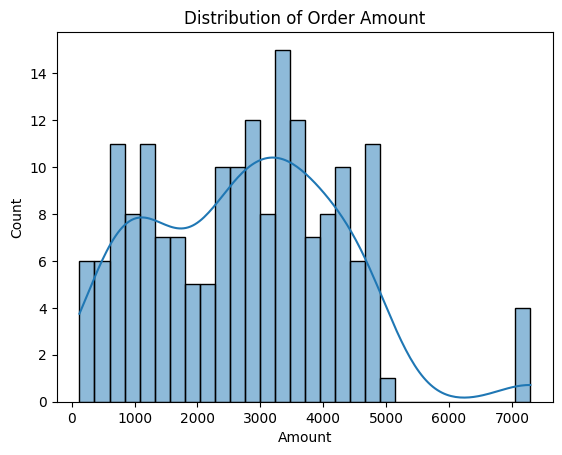

In [161]:
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Distribution of Order Amount")
plt.show()

### Category Count

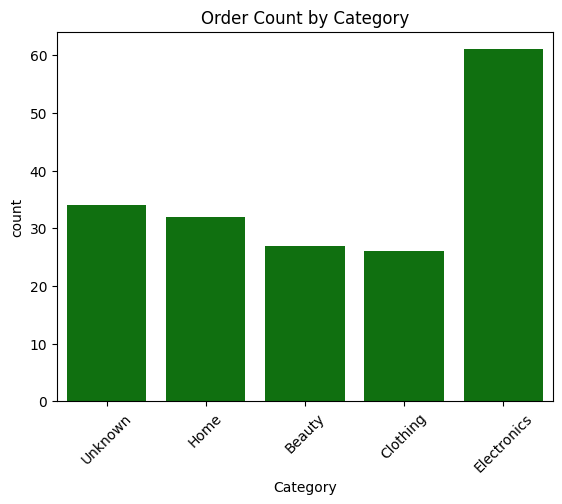

In [166]:
sns.countplot(x='Category', data=df , color = 'Green')
plt.title("Order Count by Category")
plt.xticks(rotation=45)
plt.show()

### Delivery Days

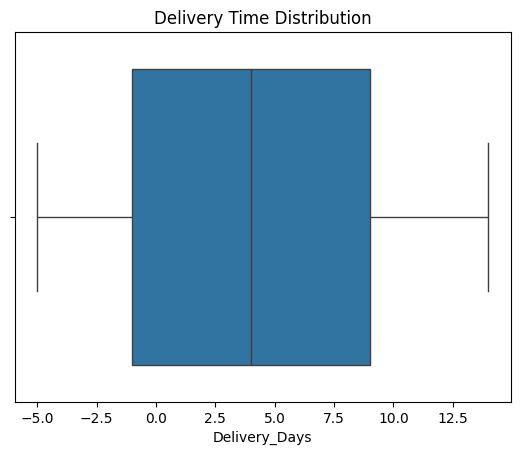

In [163]:
sns.boxplot(x=df['Delivery_Days'])
plt.title("Delivery Time Distribution")
plt.show()

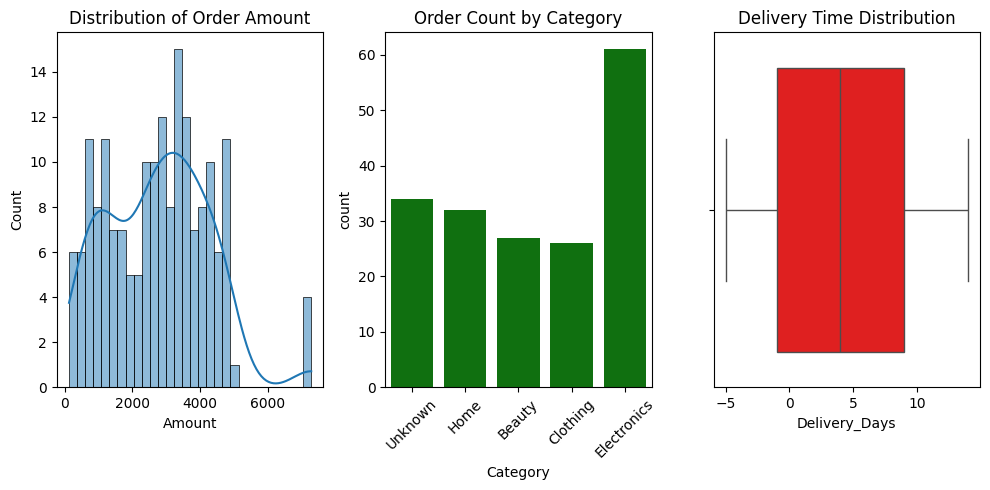

In [168]:
plt.figure(figsize = (10,5))

plt.subplot(1,3,1)
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Distribution of Order Amount")

plt.subplot(1,3,2)
sns.countplot(x='Category', data=df , color = 'Green')
plt.title("Order Count by Category")
plt.xticks(rotation=45)

plt.subplot(1,3,3)
sns.boxplot(x=df['Delivery_Days'] , color = 'red')
plt.title("Delivery Time Distribution")

plt.tight_layout()
plt.show()

### BIVARIATE ANALYSIS (Two Variables)

### 1: Category vs Return Rate

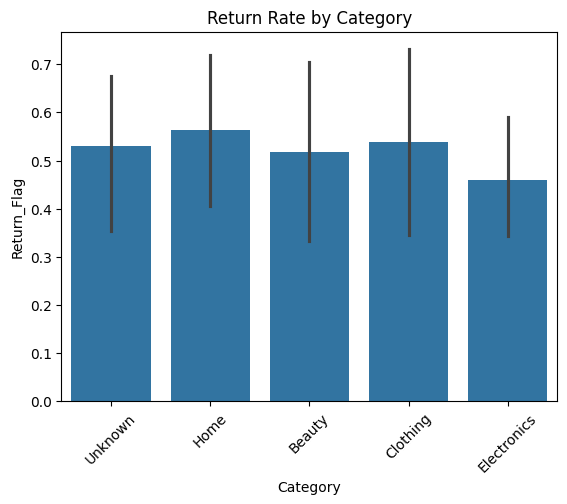

In [170]:
sns.barplot(x='Category', y='Return_Flag', data=df )
plt.title("Return Rate by Category")
plt.xticks(rotation=45)
plt.show()

### 2: Delivery Time vs Returns

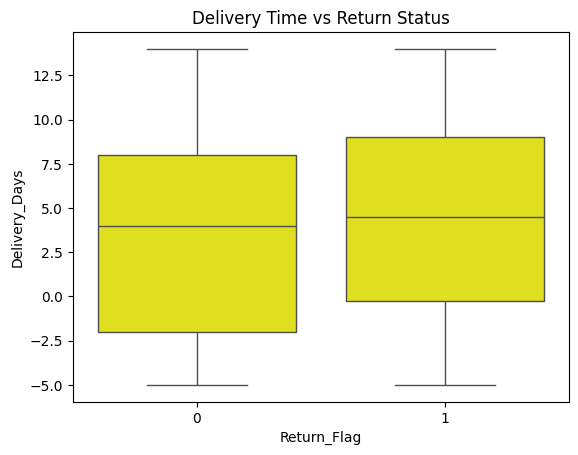

In [172]:
sns.boxplot(x='Return_Flag', y='Delivery_Days', data=df , color = 'yellow')
plt.title("Delivery Time vs Return Status")
plt.show()

### 3: Amount vs Returns

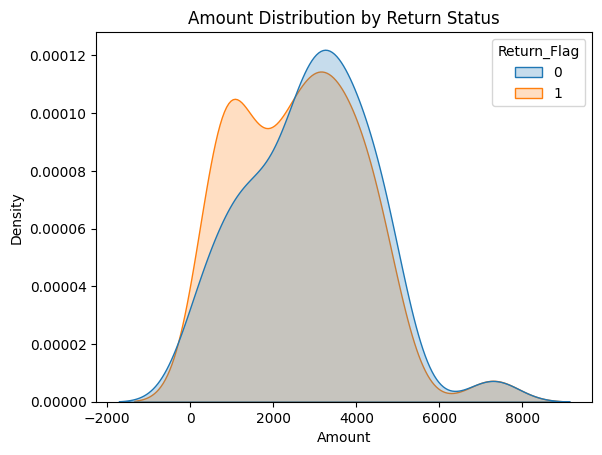

In [173]:
sns.kdeplot(data=df, x='Amount', hue='Return_Flag', fill=True)
plt.title("Amount Distribution by Return Status")
plt.show()

### MULTIVARIATE ANALYSIS (3+ Variables)

### 1: Category + Zone vs Returns

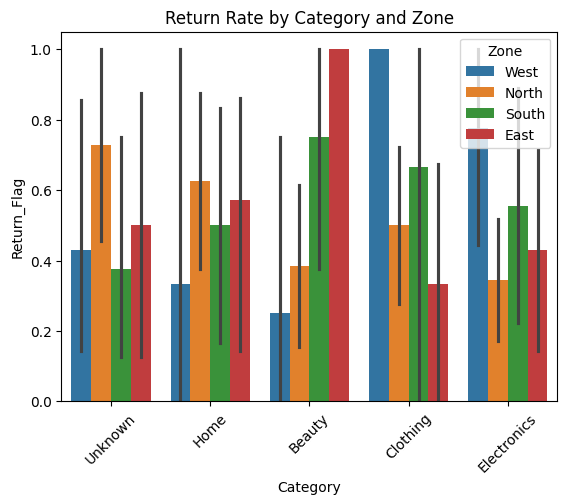

In [179]:
sns.barplot(x='Category', y='Return_Flag', hue='Zone', data=df)
plt.title("Return Rate by Category and Zone")
plt.xticks(rotation=45)
plt.show()

### 2: Correlation Heatmap

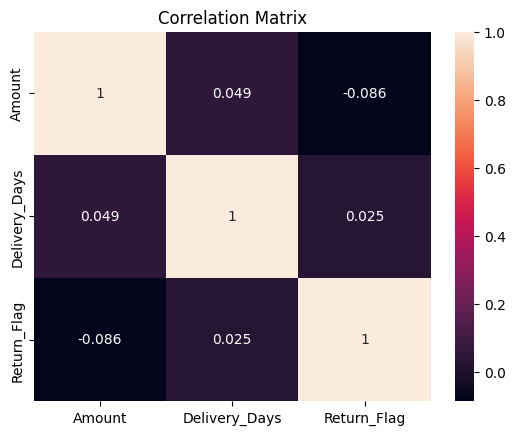

In [180]:
sns.heatmap(df[['Amount','Delivery_Days','Return_Flag']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

### 3: Delivery + Category impact

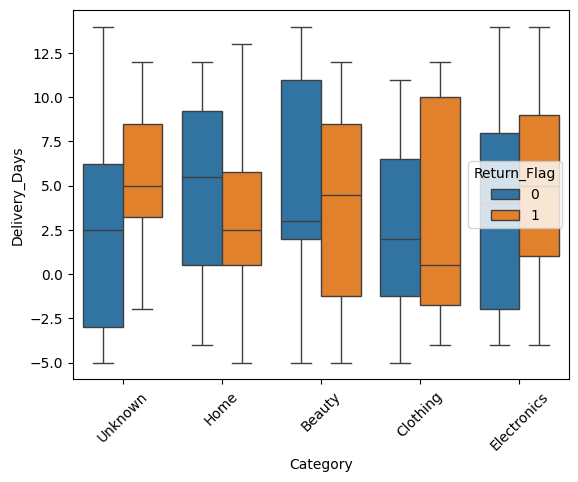

In [181]:
sns.boxplot(x='Category', y='Delivery_Days', hue='Return_Flag', data=df)
plt.xticks(rotation=45)
plt.show()

# Conclusion